# LSTM Text Branch — Fashion Shopping Assistant
**Project:** Fashion Classification & Similarity
**Module:** LSTM Text Encoder

---

## 1. Install Dependencies

In [58]:
!pip install -q tensorflow pandas numpy scikit-learn matplotlib seaborn
print('✅ Libraries installed')

✅ Libraries installed


## 2. Upload Dataset

In [ ]:
from google.colab import files
print(' final_fashion_dataset.csv')
uploaded = files.upload()
csv_name = list(uploaded.keys())[0]
print(f' : {csv_name}')

⬆️ final_fashion_dataset.csv


Saving final_fashion_dataset  LAST (1).csv to final_fashion_dataset  LAST (1) (2).csv
✅ : final_fashion_dataset  LAST (1) (2).csv


## 3. Data Cleaning & Text Preprocessing

In [ ]:
import pandas as pd
import numpy as np
import re

# ── ──
df = pd.read_csv(csv_name, encoding='latin-1')
print(f' : {df.shape}')
print(df['label'].value_counts())

# ── ──

# 1) null
df = df.dropna(subset=['description', 'label'])

# 2) "Category: xxx" description
df['description'] = df['description'].str.replace(r'\.?\s*Category:.*$', '', regex=True)

# 3)
df['description'] = df['description'].str.strip()
df['description'] = df['description'].str.replace(r'[^a-zA-Z0-9 .,\'-]', ' ', regex=True)
df['description'] = df['description'].str.replace(r'\s+', ' ', regex=True).str.strip()

# 4) (ta ta ta)
def is_repetitive(text):
 words = str(text).split()
 if len(words) < 4: return False
 unique_ratio = len(set(words)) / len(words)
 return unique_ratio < 0.4 # 60%
df['description'] = df['description'].str.replace(r'\b(\w+)( \1\b)+', r'\1', regex=True)
df = df[~df['description'].apply(is_repetitive)]

# 5) descriptions ( 3 )
df = df[df['description'].str.split().str.len() >= 3]

df = df.reset_index(drop=True)

print(f'\n : {df.shape}')
print('\n :')
print(df['label'].value_counts())
print('\n :')
for cls in df['label'].unique():
 ex = df[df['label']==cls]['description'].iloc[0]
 print(f' [{cls}] {ex}')

📦 : (1211, 3)
label
bags       210
shoes      208
outfit     192
pants      168
shirts     168
skirt      153
watches    106
Name: count, dtype: int64

✅ : (1173, 3)

📊 :
label
bags       210
shoes      206
outfit     181
shirts     164
pants      153
skirt      153
watches    106
Name: count, dtype: int64

📝 :
 [bags] a black handbag with white bow
 [outfit] adidas originals track jacket - green
 [pants] adidas originals sweat pants in navy
 [shirts] blue and white shirt
 [shoes] a nike gray shoes
 [skirt] a woman in a black crop top and skirt
 [watches] a silver smartwatch with a white strap


## 4. Augment Training Data

In [61]:
# ── Add extra skirt samples ──

new_skirt_samples = pd.DataFrame({
    'description': [
        "casual red skirt for summer",
        "black pleated skirt for women",
        "long floral skirt fashion style",
        "comfortable denim skirt",
        "mini skirt outfit for girls",
        "high waist elegant skirt",
        "stylish cotton skirt",
        "casual women skirt outfit",
        "short fashion skirt",
        "daily wear skirt style"
    ],

    'label': [
        "skirt",
        "skirt",
        "skirt",
        "skirt",
        "skirt",
        "skirt",
        "skirt",
        "skirt",
        "skirt",
        "skirt"
    ]
})

extra_data = pd.DataFrame({

    'description': [

        # pants
        'casual blue denim jeans for men',
        'black cargo trousers with pockets',
        'slim fit jogging sweatpants',
        'comfortable training pants for gym',
        'wide leg casual trousers',

        # outfit
        'full casual outfit with matching clothes',
        'complete winter outfit for women',
        'streetwear outfit with hoodie and pants',
        'elegant dinner outfit set',
        'fashionable matching outfit for teenagers'
    ],

    'label': [

        'pants',
        'pants',
        'pants',
        'pants',
        'pants',

        'outfit',
        'outfit',
        'outfit',
        'outfit',
        'outfit'
    ]
})

df = pd.concat([df, extra_data], ignore_index=True)

# add samples to dataset
df = pd.concat([df, new_skirt_samples], ignore_index=True)

# reset index again
df = df.reset_index(drop=True)

## 5. Label Encoding & Train/Val/Test Split

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

NUM_CLASSES = len(le.classes_)
print(f' : {NUM_CLASSES}')
print(' Mapping:')
for i, cls in enumerate(le.classes_):
 print(f' {i} → {cls}')

# Train / Val / Test Split (70 / 15 / 15)
X = df['description'].values
y = df['label_encoded'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f'\n :')
print(f' Train : {len(X_train):4d} ({len(X_train)/len(X)*100:.0f}%)')
print(f' Val : {len(X_val):4d} ({len(X_val)/len(X)*100:.0f}%)')
print(f' Test : {len(X_test):4d} ({len(X_test)/len(X)*100:.0f}%)')

✅ : 7
 Mapping:
 0 → bags
 1 → outfit
 2 → pants
 3 → shirts
 4 → shoes
 5 → skirt
 6 → watches

📊 :
 Train :  835 (70%)
 Val :  179 (15%)
 Test :  179 (15%)


## 6. Tokenization & Padding

In [ ]:
import pickle
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ── Parameters ──
VOCAB_SIZE = 5000
MAX_LEN = 30
# ────────────────

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train) # fit train !

def texts_to_padded(texts):
 seqs = tokenizer.texts_to_sequences(texts)
 return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

X_train_pad = texts_to_padded(X_train)
X_val_pad = texts_to_padded(X_val)
X_test_pad = texts_to_padded(X_test)

# tokenizer
with open('tokenizer.pkl', 'wb') as f:
 pickle.dump(tokenizer, f)

print(f' Tokenization !')
print(f' Vocabulary size : {len(tokenizer.word_index)}')
print(f' Train shape : {X_train_pad.shape}')
print(f' Val shape : {X_val_pad.shape}')
print(f' Test shape : {X_test_pad.shape}')
print(f'\n :')
print(f' Text : "{X_train[0]}"')
print(f' Tokens: {X_train_pad[0]}')

✅ Tokenization !
 Vocabulary size : 357
 Train shape : (835, 30)
 Val shape : (179, 30)
 Test shape : (179, 30)

🔍 :
 Text : "a woman in a black top and beige skirt"
 Tokens: [ 2 12  6  2  4 31  3 30 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0]


## 7. Build LSTM Model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, LSTM, Bidirectional,
    Dense, Dropout, BatchNormalization, Lambda
)

# ── Parameters ──
EMBEDDING_DIM = 128
LSTM_UNITS = 128
OUTPUT_DIM = 512
DROPOUT_RATE = 0.5
# ────────────────


def build_lstm_encoder():

    """
    LSTM Text Encoder
    Text → Embedding → BiLSTM → Dense → Vector
    """

    inp = Input(shape=(MAX_LEN,), name='text_input')

    # Embedding
    x = Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        name='embedding'
    )(inp)

    # First BiLSTM
    x = Bidirectional(
        LSTM(
            LSTM_UNITS // 2,
            return_sequences=True,
            dropout=DROPOUT_RATE
        ),
        name='bilstm_1'
    )(x)

    x = BatchNormalization()(x)

    # Second BiLSTM
    x = Bidirectional(
        LSTM(
            LSTM_UNITS // 2,
            return_sequences=False,
            dropout=DROPOUT_RATE
        ),
        name='bilstm_2'
    )(x)

    x = BatchNormalization()(x)

    x = Dropout(DROPOUT_RATE)(x)

    # Projection Layer
    x = Dense(
        OUTPUT_DIM,
        activation='relu',
        name='projection'
    )(x)

    # L2 Normalization

# L2 Normalization
out = Lambda(
    lambda x: tf.math.l2_normalize(x, axis=1),
    output_shape=(OUTPUT_DIM,),
    name='text_vector'
)(x)

return Model(inp, out, name='LSTM_Text_Encoder')


# ── Classifier Wrapper ──
def build_lstm_classifier():

    encoder = build_lstm_encoder()

    inp = encoder.input
    vec = encoder.output

    x = Dense(256, activation='relu')(vec)

    x = Dropout(0.3)(x)

    out = Dense(
        NUM_CLASSES,
        activation='softmax',
        name='class_output'
    )(x)

    model = Model(inp, out, name='LSTM_Classifier')

    return model, encoder


# Build Model
classifier, lstm_encoder = build_lstm_classifier()

# Compile
classifier.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Summary
classifier.summary()

print(f"\n Text Vector size: {OUTPUT_DIM}")


Model: "LSTM_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_input (InputLayer)         │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 30, 128)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 30, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection (Dense)              │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vector (Lambda)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_output (Dense)            │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,037,831 (3.96 MB)

 Trainable params: 1,037,319 (3.96 MB)

 Non-trainable params: 512 (2.00 KB)


🔢 Text Vector size: 512


## 8. Train the Model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
 EarlyStopping(
 monitor='val_accuracy', patience=5,
 restore_best_weights=True, verbose=1
 ),
 ReduceLROnPlateau(
 monitor='val_loss', factor=0.5,
 patience=3, min_lr=1e-6, verbose=1
 ),
 ModelCheckpoint(
 'best_lstm.h5', monitor='val_accuracy',
 save_best_only=True, verbose=1
 )
]

print(' ...')
history = classifier.fit(
 X_train_pad, y_train,
 validation_data=(X_val_pad, y_val),
 epochs=30,
 batch_size=32,
 callbacks=callbacks,
 verbose=1
)
print('\n !')

🚀 ...
Epoch 1/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.1669 - loss: 1.9367
Epoch 1: val_accuracy improved from None to 0.17318, saving model to best_lstm.h5



Epoch 1: finished saving model to best_lstm.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 13s 124ms/step - accuracy: 0.1808 - loss: 1.9291 - val_accuracy: 0.1732 - val_loss: 1.9075 - learning_rate: 0.0010
Epoch 2/30
26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.2753 - loss: 1.8619
Epoch 2: val_accuracy did not improve from 0.17318
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.3126 - loss: 1.8147 - val_accuracy: 0.1732 - val_loss: 2.1155 - learning_rate: 0.0010
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.3660 - loss: 1.5163
Epoch 3: val_accuracy improved from 0.17318 to 0.21229, saving model to best_lstm.h5



Epoch 3: finished saving model to best_lstm.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.4000 - loss: 1.4406 - val_accuracy: 0.2123 - val_loss: 2.0371 - learning_rate: 0.0010
Epoch 4/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5926 - loss: 1.1183
Epoch 4: val_accuracy improved from 0.21229 to 0.35754, saving model to best_lstm.h5



Epoch 4: finished saving model to best_lstm.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.5988 - loss: 1.0673 - val_accuracy: 0.3575 - val_loss: 1.5872 - learning_rate: 0.0010
Epoch 5/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6178 - loss: 0.8400
Epoch 5: val_accuracy improved from 0.35754 to 0.46927, saving model to best_lstm.h5



Epoch 5: finished saving model to best_lstm.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.6144 - loss: 0.8189 - val_accuracy: 0.4693 - val_loss: 1.3287 - learning_rate: 0.0010
Epoch 6/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6511 - loss: 0.7016
Epoch 6: val_accuracy improved from 0.46927 to 0.61453, saving model to best_lstm.h5


...


Epoch 14: finished saving model to best_lstm.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8623 - loss: 0.3206 - val_accuracy: 0.8603 - val_loss: 0.3866 - learning_rate: 0.0010
Epoch 15/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8515 - loss: 0.3732
Epoch 15: val_accuracy improved from 0.86034 to 0.86592, saving model to best_lstm.h5



Epoch 15: finished saving model to best_lstm.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8503 - loss: 0.3709 - val_accuracy: 0.8659 - val_loss: 0.3546 - learning_rate: 0.0010
Epoch 16/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8420 - loss: 0.3588
Epoch 16: val_accuracy did not improve from 0.86592
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8515 - loss: 0.3441 - val_accuracy: 0.8492 - val_loss: 0.4031 - learning_rate: 0.0010
Epoch 17/30
26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8691 - loss: 0.3245
Epoch 17: val_accuracy did not improve from 0.86592
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8731 - loss: 0.3325 - val_accuracy: 0.8659 - val_loss: 0.3683 - learning_rate: 0.0010
Epoch 18/30
24/27 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8709 - loss: 0.3371
Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 18: val_accuracy improved from 0.86592 to 0.87709, saving model to best_lstm.h5



Epoch 18: finished saving model to best_lstm.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8707 - loss: 0.3038 - val_accuracy: 0.8771 - val_loss: 0.3864 - learning_rate: 0.0010
Epoch 19/30
25/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8905 - loss: 0.2615
Epoch 19: val_accuracy improved from 0.87709 to 0.88827, saving model to best_lstm.h5



Epoch 19: finished saving model to best_lstm.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8886 - loss: 0.2600 - val_accuracy: 0.8883 - val_loss: 0.3717 - learning_rate: 5.0000e-04
Epoch 20/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8728 - loss: 0.2810
Epoch 20: val_accuracy did not improve from 0.88827
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8731 - loss: 0.2766 - val_accuracy: 0.8827 - val_loss: 0.3596 - learning_rate: 5.0000e-04
Epoch 21/30
25/27 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8905 - loss: 0.2571
Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 21: val_accuracy improved from 0.88827 to 0.89385, saving model to best_lstm.h5



Epoch 21: finished saving model to best_lstm.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8922 - loss: 0.2736 - val_accuracy: 0.8939 - val_loss: 0.3838 - learning_rate: 5.0000e-04
Epoch 22/30
24/27 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8913 - loss: 0.2762
Epoch 22: val_accuracy did not improve from 0.89385
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8826 - loss: 0.2887 - val_accuracy: 0.8939 - val_loss: 0.3839 - learning_rate: 2.5000e-04
Epoch 23/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8936 - loss: 0.2964
Epoch 23: val_accuracy did not improve from 0.89385
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8862 - loss: 0.2770 - val_accuracy: 0.8659 - val_loss: 0.3603 - learning_rate: 2.5000e-04
Epoch 24/30
24/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8652 - loss: 0.3024
Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 24: val_accuracy did not improve from 0.89385
27/27 ━━━━━━━━━━━━━━━━━━━━ 

## 9. Plot Training Curves

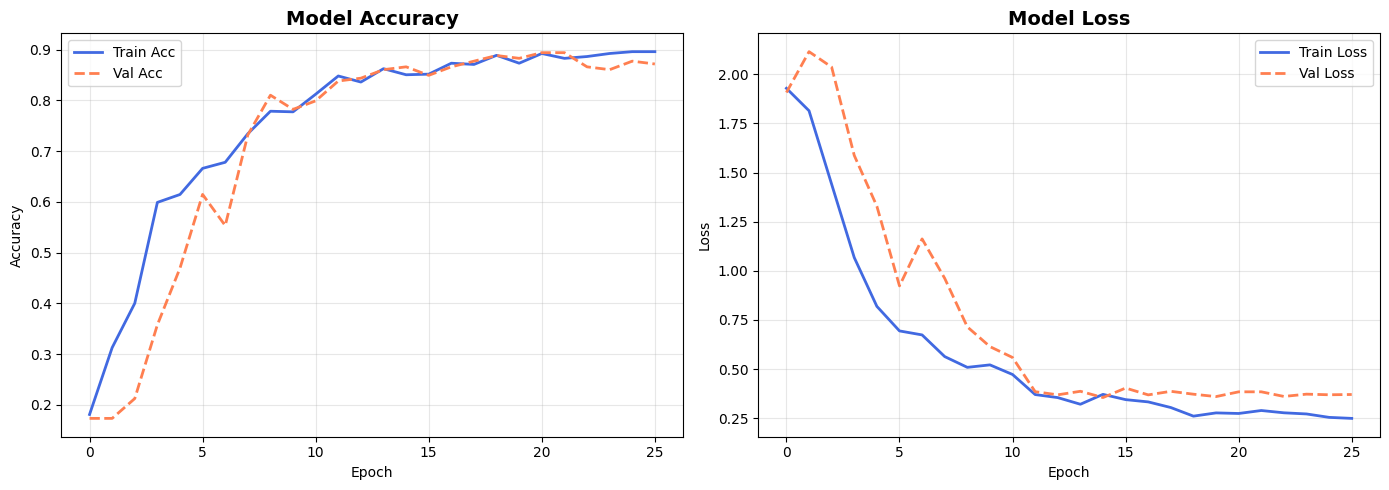


🏆 Val Accuracy: 89.39%


In [66]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Acc', color='royalblue', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Acc', color='coral', linewidth=2, linestyle='--')
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Train Loss', color='royalblue', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss', color='coral', linewidth=2, linestyle='--')
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

best_val_acc = max(history.history['val_accuracy'])
print(f'\n🏆 Val Accuracy: {best_val_acc*100:.2f}%')

## 10. Evaluate on Test Set

📊 TEST SET RESULTS
Test Accuracy : 85.47%
Test Loss : 0.3174

Classification Report:
-------------------------------------------------------
              precision    recall  f1-score   support

        bags       0.97      1.00      0.98        32
      outfit       0.83      0.71      0.77        28
       pants       0.50      0.43      0.47        23
      shirts       0.66      0.84      0.74        25
       shoes       1.00      0.97      0.98        31
       skirt       1.00      1.00      1.00        24
     watches       1.00      1.00      1.00        16

    accuracy                           0.85       179
   macro avg       0.85      0.85      0.85       179
weighted avg       0.86      0.85      0.85       179



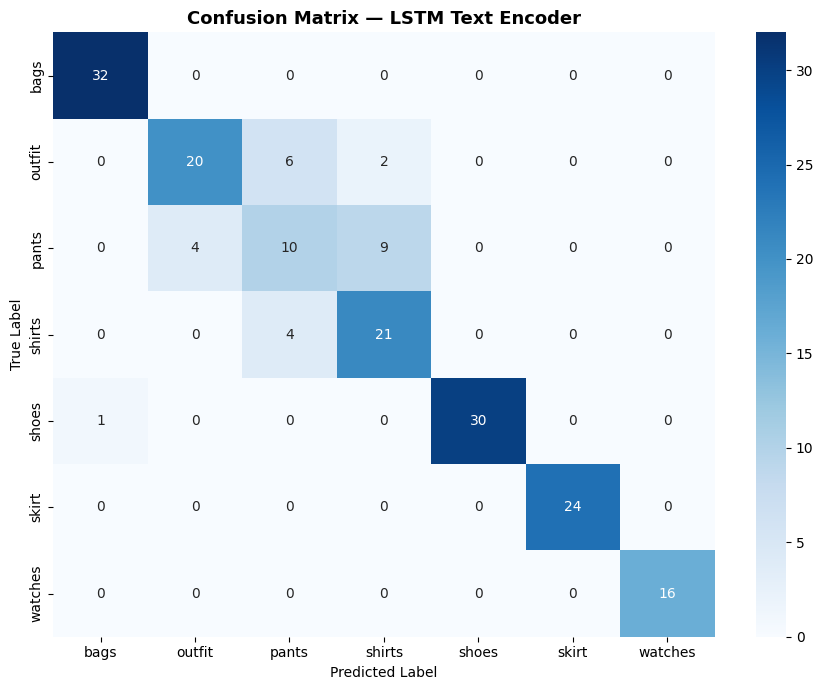

In [67]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

#
classifier.load_weights('best_lstm.h5')

y_pred_probs = classifier.predict(X_test_pad, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

test_loss, test_acc = classifier.evaluate(X_test_pad, y_test, verbose=0)

print('='*55)
print('📊 TEST SET RESULTS')
print('='*55)
print(f'Test Accuracy : {test_acc*100:.2f}%')
print(f'Test Loss : {test_loss:.4f}')
print()
print('Classification Report:')
print('-'*55)
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(
 cm, annot=True, fmt='d', cmap='Blues',
 xticklabels=le.classes_, yticklabels=le.classes_
)
plt.title('Confusion Matrix — LSTM Text Encoder', fontsize=13, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

## 11. Semantic Similarity — Cosine Similarity

✅ Text Vectors Generated!
Shape: (5, 512) (text → vector 512)
L2 Norms (~1.0): [1. 1. 1. 1. 1.]

🔢 Cosine Similarity Matrix:
(1.0 = identical, 0.0 = unrelated)

              black bag  sports shoes  cargo pants  gray hoodie  red skirt
black bag         1.000         0.077        0.107        0.374      0.166
sports shoes      0.077         1.000        0.078        0.230      0.059
cargo pants       0.107         0.078        1.000        0.594      0.098
gray hoodie       0.374         0.230        0.594        1.000      0.015
red skirt         0.166         0.059        0.098        0.015      1.000


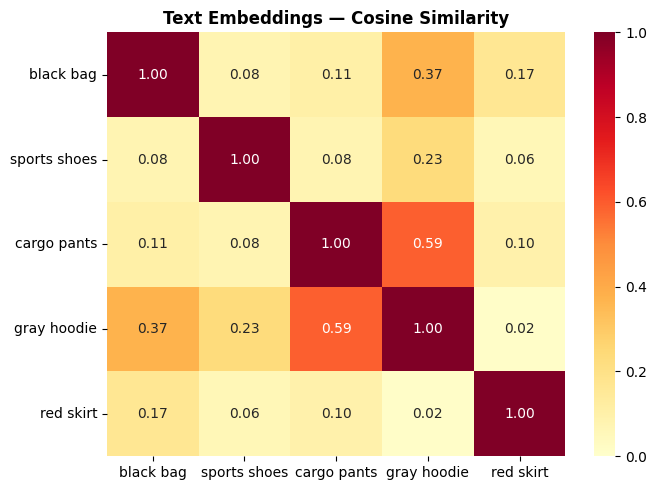

In [68]:
# ── Sample Texts for Semantic Similarity ──
sample_texts = [
    'black leather handbag for women with gold chain',
    'comfortable white running shoes for sports',
    'blue denim cargo pants for casual wear',
    'gray oversized hoodie made from fleece',
    'red floral skirt for summer fashion'
]

# Convert text → padded sequences
sample_pad = texts_to_padded(sample_texts)

# Generate text embeddings
vectors = lstm_encoder.predict(sample_pad, verbose=0)

print('✅ Text Vectors Generated!')
print(f'Shape: {vectors.shape} (text → vector {vectors.shape[1]})')

# ── Check L2 Normalization ──
norms = np.linalg.norm(vectors, axis=1)
print(f'L2 Norms (~1.0): {norms.round(4)}')

# ── Cosine Similarity ──
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(vectors)

print('\n🔢 Cosine Similarity Matrix:')
print('(1.0 = identical, 0.0 = unrelated)\n')

labels_short = [
    'black bag',
    'sports shoes',
    'cargo pants',
    'gray hoodie',
    'red skirt'
]

sim_df = pd.DataFrame(
    sim_matrix.round(3),
    index=labels_short,
    columns=labels_short
)

print(sim_df.to_string())

# ── Visualization ──
plt.figure(figsize=(7, 5))

sns.heatmap(
    sim_matrix,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    xticklabels=labels_short,
    yticklabels=labels_short,
    vmin=0,
    vmax=1
)

plt.title('Text Embeddings — Cosine Similarity', fontweight='bold')
plt.tight_layout()

plt.savefig('cosine_similarity.png', dpi=120)

plt.show()

## 12. Generate & Save All Text Vectors

In [69]:
# vectors
all_descriptions_pad = texts_to_padded(df['description'].values)
all_vectors = lstm_encoder.predict(all_descriptions_pad, verbose=1, batch_size=64)

print(f'✅ {all_vectors.shape[0]} text vector')
print(f' Shape: {all_vectors.shape}')

# vectors
np.save('lstm_text_vectors.npy', all_vectors)

# encoder
lstm_encoder.save('lstm_text_encoder.h5')

# label info
import json
config = {
 'output_dim' : int(OUTPUT_DIM),
 'vocab_size' : int(VOCAB_SIZE),
 'max_len' : int(MAX_LEN),
 'embedding_dim': int(EMBEDDING_DIM),
 'lstm_units' : int(LSTM_UNITS),
 'num_classes' : int(NUM_CLASSES),
 'classes' : list(le.classes_),
 'test_accuracy': float(round(test_acc, 4))
}
with open('lstm_config.json', 'w') as f:
 json.dump(config, f, indent=2)

print('\n💾 :')
print(' lstm_text_encoder.h5 ← ')
print(' lstm_text_vectors.npy ← vectors')
print(' tokenizer.pkl ← tokenizer')
print(' lstm_config.json ← config')

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


✅ 1193 text vector
 Shape: (1193, 512)

💾 :
 lstm_text_encoder.h5 ← 
 lstm_text_vectors.npy ← vectors
 tokenizer.pkl ← tokenizer
 lstm_config.json ← config


## 13. Inference on Sample Texts

In [70]:
test_texts = [

    # Bags
    "designer crossbody bag with premium leather finish",
    "large travel duffle handbag for women",
    "mini shoulder purse with metal strap",

    # Skirt
    "high waist pencil skirt for office wear",
    "flowy maxi skirt with elegant floral print",
    "black tennis skirt for sporty outfits",

    # Shoes
    "lightweight running sneakers with foam sole",
    "classic leather oxford shoes for formal events",
    "comfortable slip on walking shoes",

    # Shirts
    "oversized cotton t shirt with graphic print",
    "formal striped button down shirt",
    "casual polo shirt for summer",

    # Pants
    "relaxed fit cargo trousers with side pockets",
    "slim fit ripped denim jeans",
    "black jogger sweatpants for gym",

    # Watches
    "luxury analog wristwatch with silver dial",
    "smart fitness watch with heart rate tracking",
    "minimal black leather strap watch",

    # Outfit
    "stylish winter outfit with hoodie and jeans",
    "casual streetwear outfit for teenagers",
    "elegant evening outfit for formal dinner"
]

## 14. Run Predictions

In [71]:
for text in test_texts:

    seq = texts_to_padded([text])

    pred = classifier.predict(seq, verbose=0)

    pred_class = le.inverse_transform([np.argmax(pred)])[0]

    confidence = np.max(pred)

    print("="*60)
    print("Text:", text)
    print("Predicted:", pred_class)
    print("Confidence:", round(float(confidence), 3))

Text: designer crossbody bag with premium leather finish
Predicted: bags
Confidence: 0.999
Text: large travel duffle handbag for women
Predicted: bags
Confidence: 0.999
Text: mini shoulder purse with metal strap
Predicted: bags
Confidence: 0.999
Text: high waist pencil skirt for office wear
Predicted: skirt
Confidence: 0.999
Text: flowy maxi skirt with elegant floral print
Predicted: skirt
Confidence: 0.999
Text: black tennis skirt for sporty outfits
Predicted: skirt
Confidence: 0.999
Text: lightweight running sneakers with foam sole
Predicted: shoes
Confidence: 0.998
Text: classic leather oxford shoes for formal events
Predicted: shoes
Confidence: 0.997
Text: comfortable slip on walking shoes
Predicted: shoes
Confidence: 0.957
Text: oversized cotton t shirt with graphic print
Predicted: shirts
Confidence: 0.875
Text: formal striped button down shirt
Predicted: shirts
Confidence: 0.596
Text: casual polo shirt for summer
Predicted: shirts
Confidence: 0.87
Text: relaxed fit cargo trouser

## 15. Download Output Files (v1)

In [72]:
from google.colab import files

for f in ['lstm_text_encoder.h5', 'lstm_text_vectors.npy',
 'tokenizer.pkl', 'lstm_config.json',
 'training_curves.png', 'confusion_matrix.png', 'cosine_similarity.png']:
 files.download(f)

print('✅ !')
print()
print('📤 (Concatenation):')
print(' lstm_text_encoder.h5')
print(' lstm_text_vectors.npy')
print(' tokenizer.pkl')
print(' lstm_config.json')
print()
print(f'🏆 Test Accuracy : {test_acc*100:.2f}%')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ !

📤 (Concatenation):
 lstm_text_encoder.h5
 lstm_text_vectors.npy
 tokenizer.pkl
 lstm_config.json

🏆 Test Accuracy : 85.47%


## 16. Save Final LSTM Components

In [ ]:
# ==============================
# SAVE FINAL LSTM COMPONENTS
# ==============================

import pickle
import numpy as np

# 1) Save full classification model
classifier.save('lstm_classifier.keras')

# 2) Save text encoder only
lstm_encoder.save('lstm_text_encoder.keras')

# 3) Save text vectors / embeddings
np.save('lstm_text_vectors.npy', vectors)

# 4) Save tokenizer
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# 5) Save config
config = {
    'max_len': MAX_LEN,
    'embedding_dim': EMBEDDING_DIM,
    'lstm_units': LSTM_UNITS,
    'num_classes': NUM_CLASSES
}

with open('lstm_config.pkl', 'wb') as f:
    pickle.dump(config, f)

print('✅ ALL LSTM FILES SAVED SUCCESSFULLY')

✅ ALL LSTM FILES SAVED SUCCESSFULLY


## 17. Download All Files (v2)

In [75]:
from google.colab import files

for f in [
    'lstm_classifier.keras',
    'lstm_text_encoder.keras',
    'lstm_text_vectors.npy',
    'tokenizer.pkl',
    'lstm_config.pkl',
    'training_curves.png',
    'confusion_matrix.png',
    'cosine_similarity.png'
]:
    files.download(f)

print('✅ Download Complete')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download Complete


## 18. Download All Files (v3)

In [76]:
from google.colab import files

for f in [
    'lstm_classifier.keras',
    'lstm_text_encoder.keras',
    'lstm_text_vectors.npy',
    'tokenizer.pkl',
    'lstm_config.pkl',
    'training_curves.png',
    'confusion_matrix.png',
    'cosine_similarity.png'
]:
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>